# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("hotels.csv")
display(df.head())
print("Rows and columns:", df.shape)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Rows and columns: (9404, 32)


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The key stakeholders for this dataset are the hotel's general manager, revenue manager, reservations team, and marketing team.

2. I think the general managers goal is to have a reliable occupancy and revenue, the revenue managers goal is to see how many booked rooms will actually be occupied, the reservation team wants to manage reservations (who cancels and what is available), and the marketing team wants to see what grabs the customer's attention.

3. We are trying to see how the time between booking and arrival relate to the amount of people who cancer at the hotel, and how can the hotel can use that to improve occupancy planning.




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [5]:
print("Shape:", df.shape)
df.info()

display(df.describe(include="all").T)

print("\nMissing values by column:")
display(df.isna().sum().sort_values(ascending=False))

print("Fully duplicated rows:", df.duplicated().sum())
print("\nHotel types:")
display(df["hotel"].value_counts())

print("\nADR values below zero:", (df["adr"] < 0).sum())

Shape: (9404, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,9404,1,Resort Hotel,9404,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,9404.0,NaN,NaN,NaN,0.248299,0.432049,0.0,0.0,0.0,0.0,1.0
lead_time,9404.0,NaN,NaN,NaN,79.326244,87.584146,0.0,8.0,48.0,118.0,737.0
arrival_date_year,9404.0,NaN,NaN,NaN,2015.156104,0.443661,2015.0,2015.0,2015.0,2015.0,2017.0
arrival_date_month,9404,12,October,1610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,9404.0,NaN,NaN,NaN,37.026584,11.083421,1.0,31.0,38.0,45.0,53.0
arrival_date_day_of_month,9404.0,NaN,NaN,NaN,15.515313,9.025545,1.0,7.0,16.0,23.0,31.0
stays_in_weekend_nights,9404.0,NaN,NaN,NaN,1.15504,1.124304,0.0,0.0,1.0,2.0,13.0
stays_in_week_nights,9404.0,NaN,NaN,NaN,3.07869,2.379227,0.0,1.0,3.0,5.0,33.0
adults,9404.0,NaN,NaN,NaN,1.864738,1.198565,0.0,2.0,2.0,2.0,55.0



Missing values by column:


,0
company,8393
agent,2335
country,266
hotel,0
arrival_date_month,0
arrival_date_week_number,0
lead_time,0
is_canceled,0
stays_in_weekend_nights,0
stays_in_week_nights,0


Fully duplicated rows: 1674

Hotel types:


,count
hotel,
Resort Hotel,9404



ADR values below zero: 1


### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. From the data, I found that the row "company" is missing 8393 values out of 9404.

2. We can check what the missing company values mean or if it just doesn't have one at all. We should label them properly instead of deleting them.



## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

,is_canceled,lead_time,adr
count,9404.000000,9404.000000,9404.000000
mean,0.248299,79.326244,86.843614
std,0.432049,87.584146,53.759940
min,0.000000,0.000000,-6.380000
25%,0.000000,8.000000,45.000000
50%,0.000000,48.000000,71.550000
75%,0.000000,118.000000,120.600000
max,1.000000,737.000000,508.000000


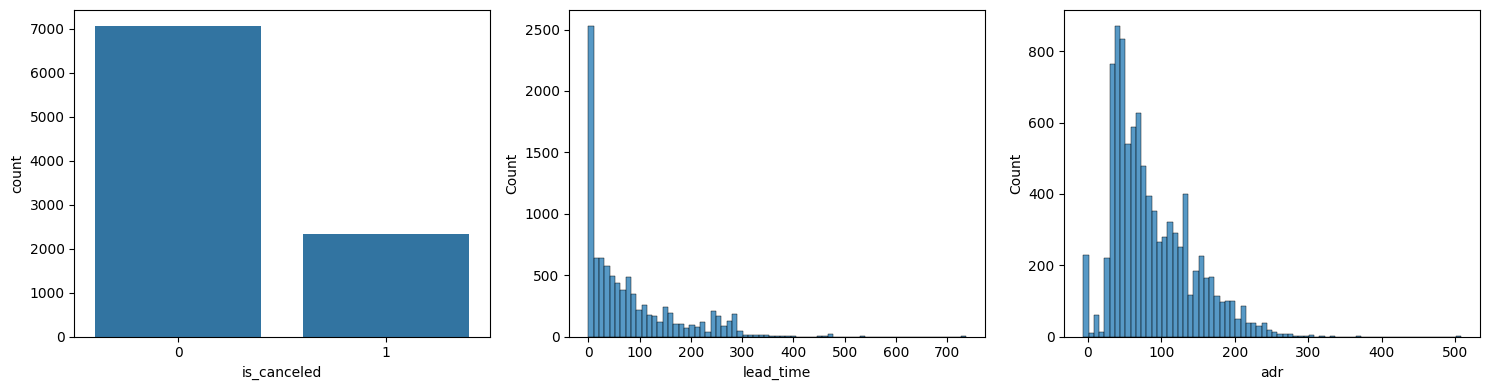

In [7]:
display(df[["is_canceled", "lead_time", "adr"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="is_canceled", ax=axes[0])
sns.histplot(data=df, x="lead_time", ax=axes[1])
sns.histplot(data=df, x="adr", ax=axes[2])

plt.tight_layout()
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:**  I was able to find is_canceled. I found that 2335 bookings were canceled and 7069 were not, making it 9404 bookings total.
- **Variable 2 – Summary and insights:**  I was able to find the lead_time which are the days between the booking and arrival time. I found that the mean was 79.3 days and the median is 48 days. It shows that customers will usually book super far in advance, making the maximum 737 days.
- **Variable 3 – Summary and insights:**  I was able to find the average daily rate. The mean is 86.84, and the median is 71.55. The only thing that seems a little concerning to watch out for is the range since it varies from -6.38 to 508.


## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

In [ ]:
# Your code to analyze variable relationships (e.g., scatterplots, grouped bars) 🔧


### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:**  
- **Relationship 2:**  


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight?
2. What kind of complexity does it involve?
3. What type of analytics would help, and why?



### ✍️ Your Response: 🔧
1.
2.
3.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?

### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1.

2.

3.

4.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"